# Experiment 3: Dose vs. Image Quality

Simulating Poisson noise at different incident photon counts ($I_0$) to analyze SNR, NPS, and object detectability (CNR).

In [1]:
import os, sys
sys.path.append(os.path.abspath("../src"))
import numpy as np
import matplotlib.pyplot as plt
from phantom import generate_qa_phantom
from forward_projection import generate_sinogram
from noise_model import generate_dose_series
from fbp import reconstruct_fbp
from nps import compute_nps
from cnr import cnr_vs_dose, compute_cnr_from_qa_phantom
from utils import display_images_grid, plot_nps_curves, plot_metric_vs_parameter

## 1. Simulate Clean Sinogram and Noisy Dose Series

In [2]:
phantom, metadata = generate_qa_phantom(size=256)
clean_sino, angles = generate_sinogram(phantom, 360)
dose_levels = [1e6, 1e5, 1e4, 1e3]
dose_series = generate_dose_series(clean_sino, dose_levels=dose_levels)

## 2. Reconstruct each dose level (Ram-Lak filter)

In [3]:
recons = {}
for dose in dose_levels:
    noisy_sino = dose_series[dose]["noisy_sinogram"]
    recons[dose] = reconstruct_fbp(noisy_sino, angles, filter_name="ram-lak")

## 3. Visual Comparison

Saved: ../results/exp3_dose_visual.png


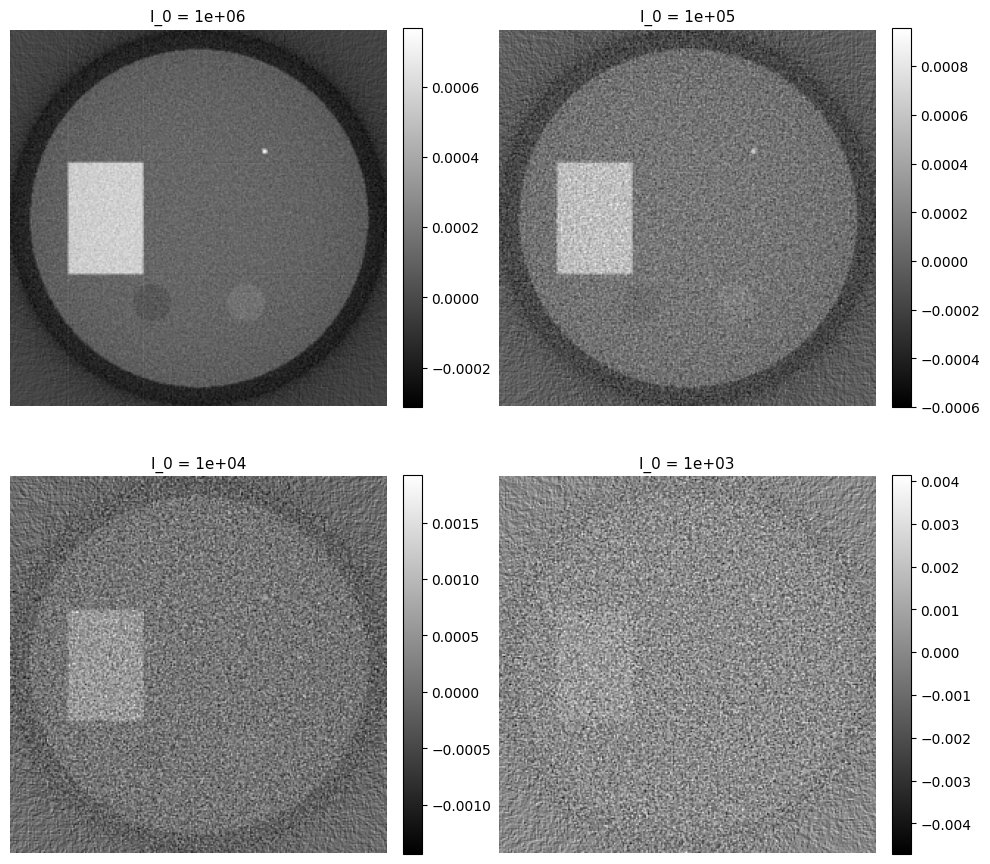

In [4]:
titles = [f"I_0 = {d:.0e}" for d in dose_levels]
images = [recons[d] for d in dose_levels]
display_images_grid(images, titles=titles, ncols=2, save_path="../results/exp3_dose_visual.png")

## 4. CNR and NPS Analysis

Saved: ../results/exp3_cnr.png


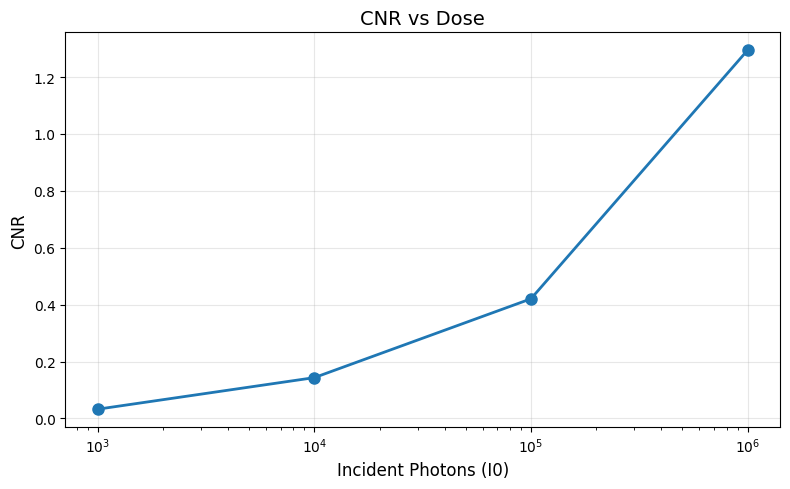

In [5]:
doses_arr, cnr_arr, details = cnr_vs_dose(recons, metadata, insert_index=0)
plot_metric_vs_parameter(doses_arr, cnr_arr, "Incident Photons (I0)", "CNR", title="CNR vs Dose", log_x=True, save_path="../results/exp3_cnr.png")

Saved: ../results/exp3_nps.png


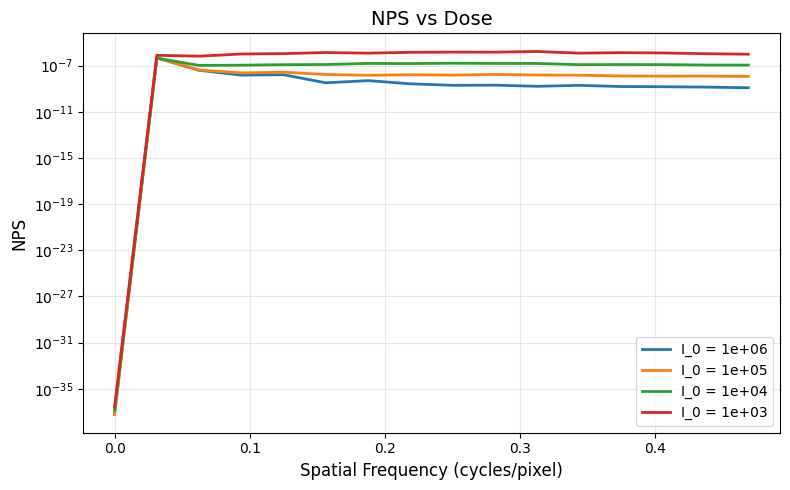

In [6]:
nps_results = {}
for dose in dose_levels:
    freq_nps, nps_vals, _, _ = compute_nps(recons[dose], roi_size=32, num_rois=8, center=(128,128))
    nps_results[f"I_0 = {dose:.0e}"] = (freq_nps, nps_vals)
plot_nps_curves(nps_results, title="NPS vs Dose", log_scale=True, save_path="../results/exp3_nps.png")